# SAM (Segment Anything Model) for Retinal Image Analysis

This notebook uses Meta's Segment Anything Model (SAM) to perform zero-shot, flexible segmentation on fundus images. Unlike YOLOv8 which requires training or pre-trained object classes, SAM can segment any object based on prompts.

## Key Concepts

**Segment Anything Model (SAM)** is a foundation model developed by Meta that:
- Accepts flexible prompts: points, bounding boxes, or text
- Generates high-quality instance segmentations
- Works on any image without training
- Produces multiple mask predictions for ambiguous prompts

For retinal images, we can:
- Click on suspicious lesions to segment them
- Draw bounding boxes around regions of interest
- Perform automatic grid-based segmentation
- Combine predictions with medical knowledge

In [3]:
# Install SAM if needed
import subprocess
import sys

try:
    import segment_anything
    print(f"SAM already installed")
except ImportError:
    print("Installing segment-anything...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "segment-anything"])
    print("Installation complete!")

SAM already installed


In [4]:
# Import necessary libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Rectangle, Circle
import os
import warnings
warnings.filterwarnings('ignore')

from segment_anything import sam_model_registry, SamPredictor, SamAutomaticMaskGenerator
from pathlib import Path

# Configure matplotlib
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['image.cmap'] = 'gray'

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Download and Load SAM Model

In [5]:
# Download SAM model
from segment_anything import sam_model_registry
import urllib.request
import os

def download_sam_model(model_type='vit_b'):
    """
    Download SAM model weights.
    
    Available models:
    - vit_b: Base model (375M parameters) - good balance
    - vit_l: Large model (1.2B parameters) - more accurate
    - vit_h: Huge model (2.5B parameters) - highest accuracy
    """
    model_urls = {
        'vit_h': 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth',
        'vit_l': 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_l_0b3195.pth',
        'vit_b': 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth',
        'vit_t': 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_t_4b8939.pth'
    }
    
    os.makedirs('models', exist_ok=True)
    model_path = f'models/sam_{model_type}.pth'
    
    if os.path.exists(model_path):
        print(f"Model already downloaded: {model_path}")
        return model_path
    
    if model_type not in model_urls:
        raise ValueError(f"Unknown model type: {model_type}")
    
    print(f"Downloading {model_type} model...")
    urllib.request.urlretrieve(model_urls[model_type], model_path)
    print(f"Downloaded to: {model_path}")
    
    return model_path

# Use vit_b (base model) for balance between speed and accuracy
model_path = download_sam_model('vit_b')

Model already downloaded: models/sam_vit_b.pth


In [6]:
import torch
# Load SAM model
print("Loading SAM model...")
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Using device: {device}")

sam = sam_model_registry['vit_b'](checkpoint=model_path)
sam.to(device=device)
predictor = SamPredictor(sam)

# Create automatic mask generator
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,  # Grid size for automatic segmentation
    pred_iou_thresh=0.86,
    stability_score_thresh=0.92,
    crop_n_layers=0,
    crop_n_points_downscale_factor=1,
    min_mask_region_area=100,
)

print("SAM model loaded successfully!")

Loading SAM model...
Using device: mps
SAM model loaded successfully!


## 2. Load Retinal Images

In [17]:
import torch

# Helper function to find images
def find_images(base_path, extensions=['.jpeg', '.jpg', '.png']):
    """Find all images in a directory and subdirectories"""
    images = []
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if any(file.lower().endswith(ext) for ext in extensions):
                images.append(os.path.join(root, file))
    return sorted(images)

# Load sample images
data_path = 'data/1-mild'
images = find_images(data_path)

print(f"Found {len(images)} images in {data_path}")
if images:
    print(f"First image: {images[0]}")

Found 213 images in data/1-mild
First image: data/1-mild/19504_left.jpeg


## 3. Automatic Segmentation (Grid-based)

In [19]:
# Perform automatic segmentation on a sample image
if len(images) > 10:
    img_path = images[10]
    print(f"Processing: {img_path}")

    # Load image
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        raise ValueError(f"Failed to read image: {img_path}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)  # keep uint8 for SAM
    print(f"Image shape: {img_rgb.shape}, dtype: {img_rgb.dtype}")
    print("Generating masks (this may take a moment)...")

    try:
        # Generate masks automatically
        masks = mask_generator.generate(img_rgb)

    except TypeError as e:
        if "MPS Tensor to float64" in str(e):
            print("MPS float64 limitation hit. Retrying on CPU...")
            device = "cpu"
            sam.to(device=device)

            # Recreate generator bound to CPU model
            mask_generator = SamAutomaticMaskGenerator(
                model=sam,
                points_per_side=32,
                pred_iou_thresh=0.86,
                stability_score_thresh=0.92,
                crop_n_layers=0,
                crop_n_points_downscale_factor=1,
                min_mask_region_area=100,
            )
            masks = mask_generator.generate(img_rgb)
        else:
            raise

    print(f"Generated {len(masks)} masks")

    # Display mask statistics
    if masks:
        areas = [mask['area'] for mask in masks]
        print("\nMask Statistics:")
        print(f"  Mean area: {np.mean(areas):.0f} pixels")
        print(f"  Min area: {np.min(areas):.0f} pixels")
        print(f"  Max area: {np.max(areas):.0f} pixels")
        print(f"  Total coverage: {np.sum(areas) / (img_rgb.shape[0] * img_rgb.shape[1]):.2%}")
else:
    print("Not enough images available.")

Processing: data/1-mild/19802_right.jpeg
Image shape: (1920, 2560, 3), dtype: uint8
Generating masks (this may take a moment)...
MPS float64 limitation hit. Retrying on CPU...
Generated 11 masks

Mask Statistics:
  Mean area: 463292 pixels
  Min area: 12153 pixels
  Max area: 3810211 pixels
  Total coverage: 103.68%


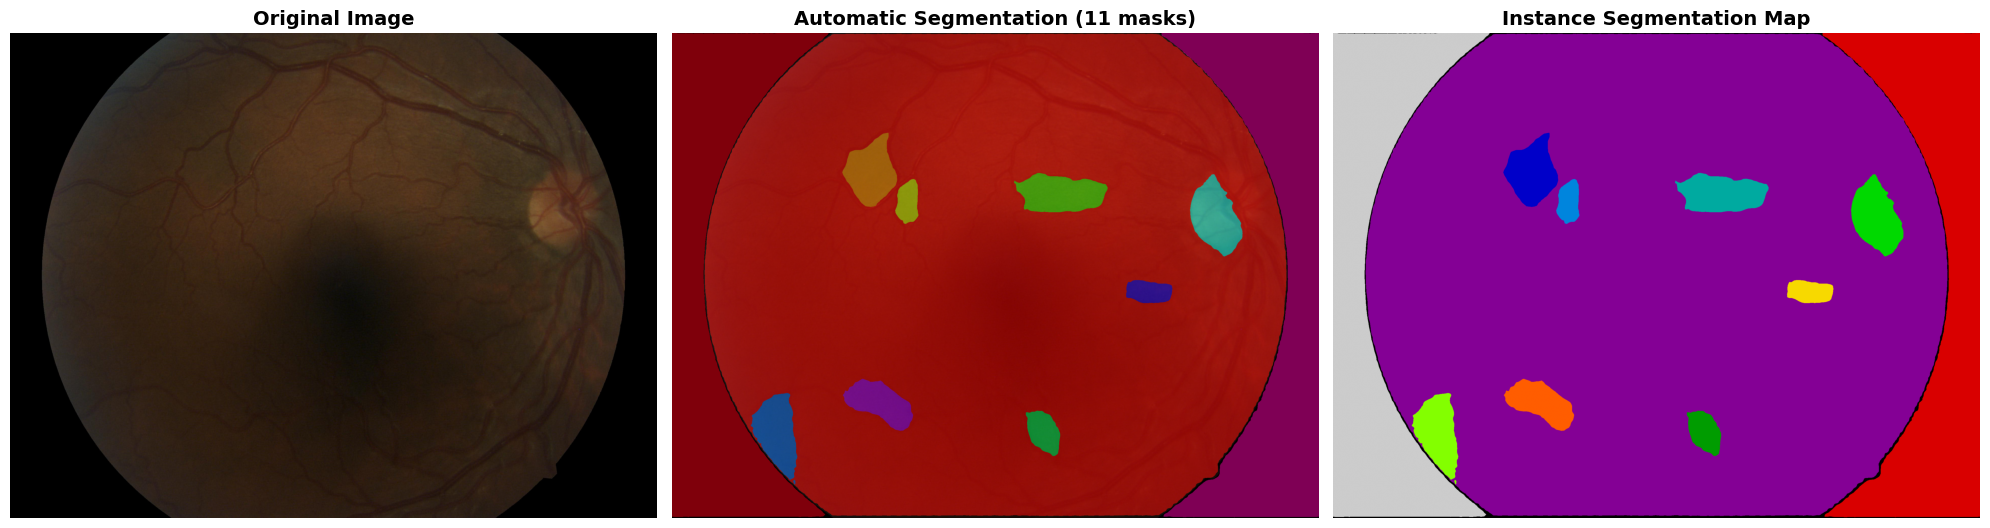

In [20]:
def show_masks(image, masks, point_label=None, point_coords=None, cmap_name='hsv'):
    """
    Visualize SAM masks on the image.
    """
    h, w = image.shape[:2]
    
    # Create colored mask image
    masks_colored = np.zeros_like(image).astype(float)
    masks_binary = np.zeros((h, w), dtype=np.uint8)
    
    if len(masks) > 0:
        cmap = plt.cm.get_cmap(cmap_name)
        colors = cmap(np.linspace(0, 1, len(masks)))
        
        for idx, mask_data in enumerate(masks):
            mask = mask_data['segmentation']
            color = colors[idx][:3]
            
            masks_colored[mask] = np.array(color) * 255
            masks_binary[mask] = idx + 1
    
    # Blend with original
    overlay = image.copy().astype(float) * 0.5 + masks_colored * 0.5
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)
    
    return overlay, masks_binary

# Visualize results
overlay, masks_binary = show_masks(img_rgb, masks)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

axes[0].imshow(img_rgb)
axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(overlay)
axes[1].set_title(f'Automatic Segmentation ({len(masks)} masks)', fontsize=14, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(masks_binary, cmap='nipy_spectral')
axes[2].set_title(f'Instance Segmentation Map', fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 4. Prompt-based Segmentation (Point Prompts)

In [21]:
# Set image for predictor
predictor.set_image(img_rgb)

# Define point prompts (simulating clicking on lesions)
# Format: [x, y] coordinates
# Labels: 1 = foreground (include), 0 = background (exclude)

# Example points (you would get these from user clicks in interactive mode)
# These should point to suspected lesion locations
input_point = np.array([
    [img_rgb.shape[1] // 3, img_rgb.shape[0] // 3],      # Sample point 1
    [img_rgb.shape[1] * 2 // 3, img_rgb.shape[0] // 2],  # Sample point 2
    [img_rgb.shape[1] // 2, img_rgb.shape[0] * 2 // 3],  # Sample point 3
])
input_label = np.array([1, 1, 1])  # All foreground points

print(f"Input points: {input_point.tolist()}")
print(f"Input labels: {input_label.tolist()}")

# Get predictions
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,  # Return multiple mask hypotheses
)

print(f"\nPrediction Results:")
print(f"  Masks shape: {masks.shape}")
print(f"  Scores: {scores}")
print(f"  Best mask score: {scores.max():.3f}")

Input points: [[853, 640], [1706, 960], [1280, 1280]]
Input labels: [1, 1, 1]

Prediction Results:
  Masks shape: (3, 1920, 2560)
  Scores: [1.0074209 1.0161953 0.5984006]
  Best mask score: 1.016


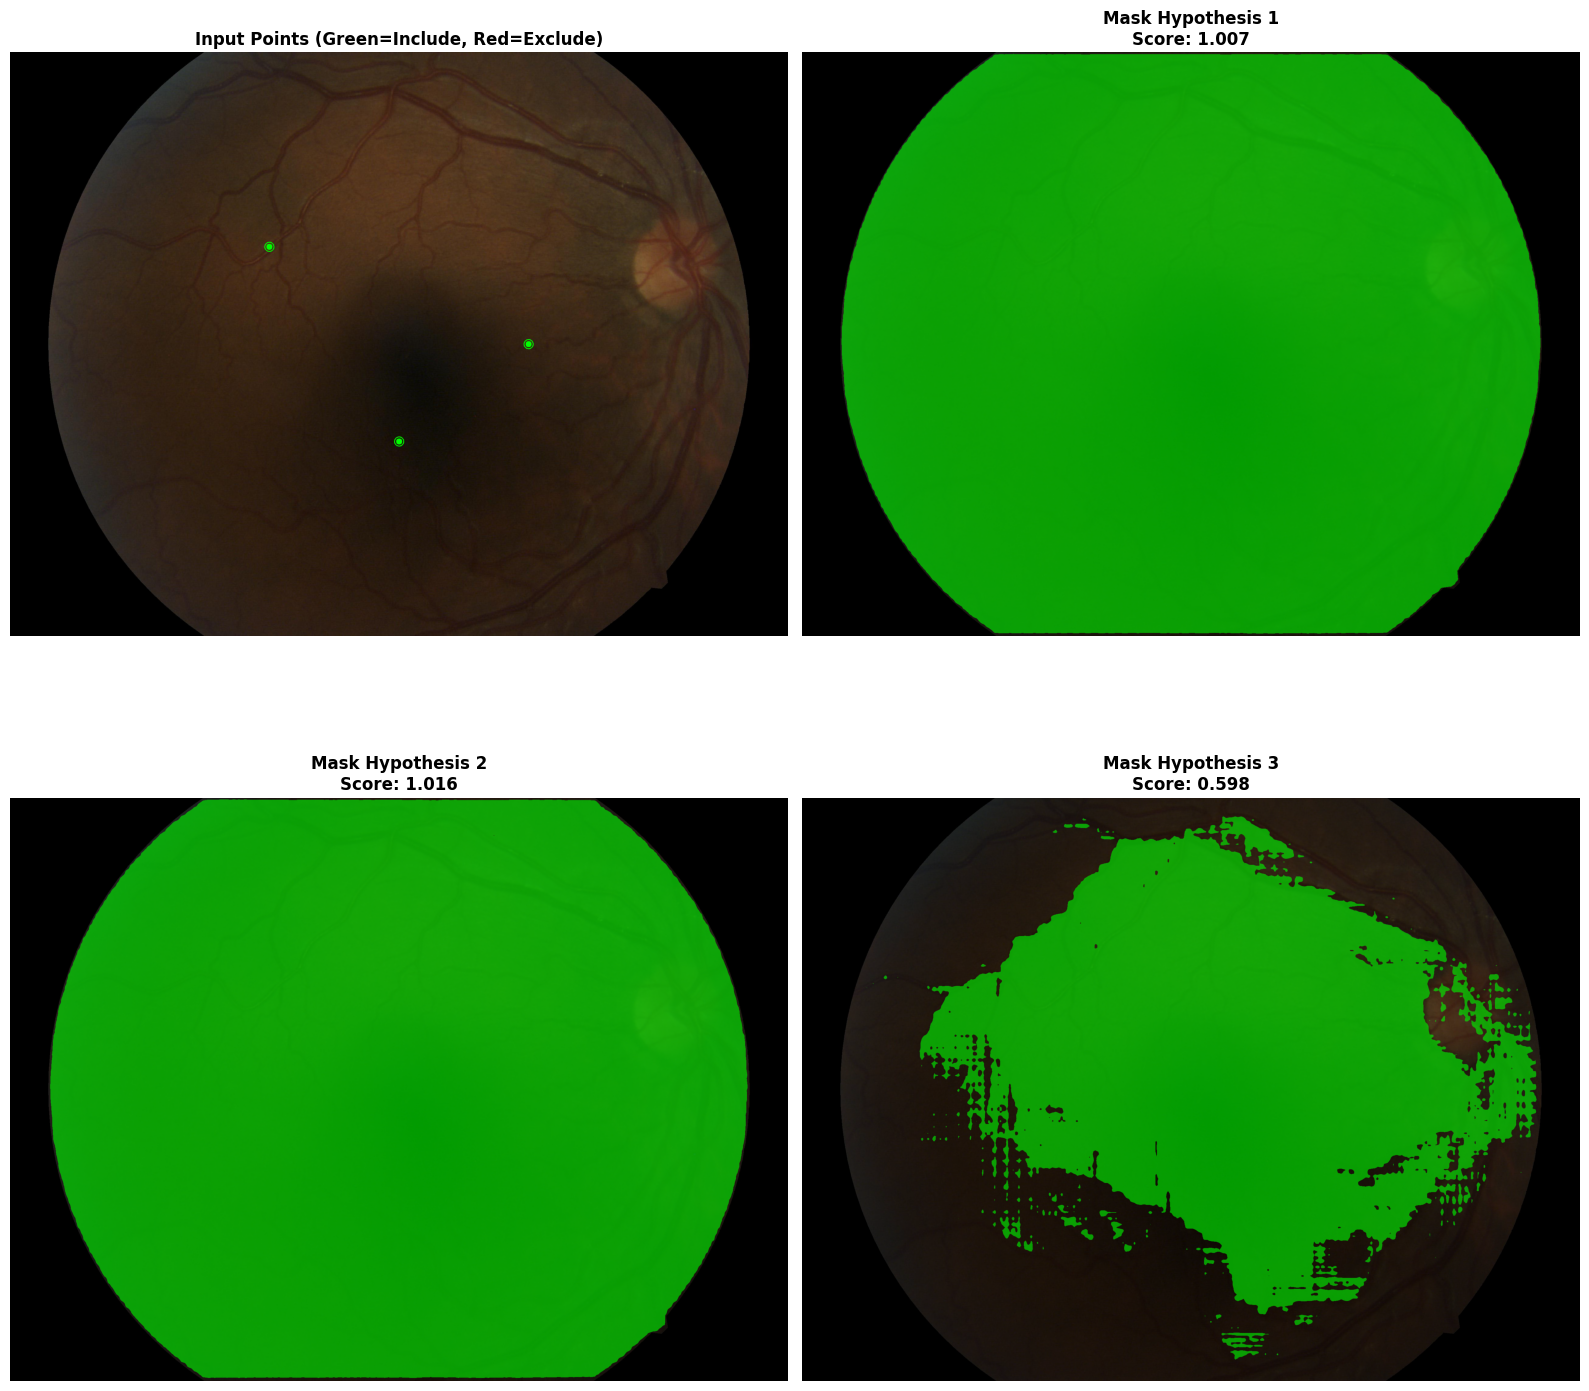


Best mask (highest score): Hypothesis 2


In [22]:
# Visualize point-based predictions
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# Original with points
img_with_points = img_rgb.copy()
for point, label in zip(input_point, input_label):
    color = (0, 255, 0) if label == 1 else (255, 0, 0)
    cv2.circle(img_with_points, tuple(point.astype(int)), 10, color, -1)
    cv2.circle(img_with_points, tuple(point.astype(int)), 15, color, 2)

axes[0, 0].imshow(img_with_points)
axes[0, 0].set_title('Input Points (Green=Include, Red=Exclude)', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Show all three mask predictions
for idx in range(3):
    row, col = (0, 1) if idx == 0 else (1, idx - 1)
    
    mask = masks[idx]
    score = scores[idx]
    
    # Create overlay
    overlay = img_rgb.copy().astype(float) * 0.6
    overlay[mask] = overlay[mask] * 0.4 + np.array([0, 255, 0]) * 0.6
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)
    
    axes[row, col].imshow(overlay)
    axes[row, col].set_title(f'Mask Hypothesis {idx + 1}\nScore: {score:.3f}', 
                            fontsize=12, fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print(f"\nBest mask (highest score): Hypothesis {np.argmax(scores) + 1}")

## 5. Bounding Box Prompts

In [23]:
# Bounding box prompt example
# Format: [x_min, y_min, x_max, y_max]

h, w = img_rgb.shape[:2]

# Define bounding boxes
input_boxes = np.array([
    [w * 0.2, h * 0.2, w * 0.4, h * 0.4],      # Box 1
    [w * 0.6, h * 0.4, w * 0.8, h * 0.6],      # Box 2
    [w * 0.3, h * 0.6, w * 0.7, h * 0.85],     # Box 3
])

# Convert to format expected by SAM
input_boxes = input_boxes.reshape(-1, 2, 2)  # Reshape to [N, 2, 2] format

print(f"Input boxes: {input_boxes.tolist()}")

# Make predictions
masks_bbox = []
scores_bbox = []

for box in input_boxes:
    mask, score, _ = predictor.predict(
        box=box[None, :],
        multimask_output=False,
    )
    masks_bbox.append(mask[0])
    scores_bbox.append(score[0])

print(f"\nGenerated {len(masks_bbox)} masks from bounding boxes")
print(f"Scores: {scores_bbox}")

Input boxes: [[[512.0, 384.0], [1024.0, 768.0]], [[1536.0, 768.0], [2048.0, 1152.0]], [[768.0, 1152.0], [1792.0, 1632.0]]]

Generated 3 masks from bounding boxes
Scores: [np.float32(0.9200054), np.float32(0.90370655), np.float32(0.60918325)]


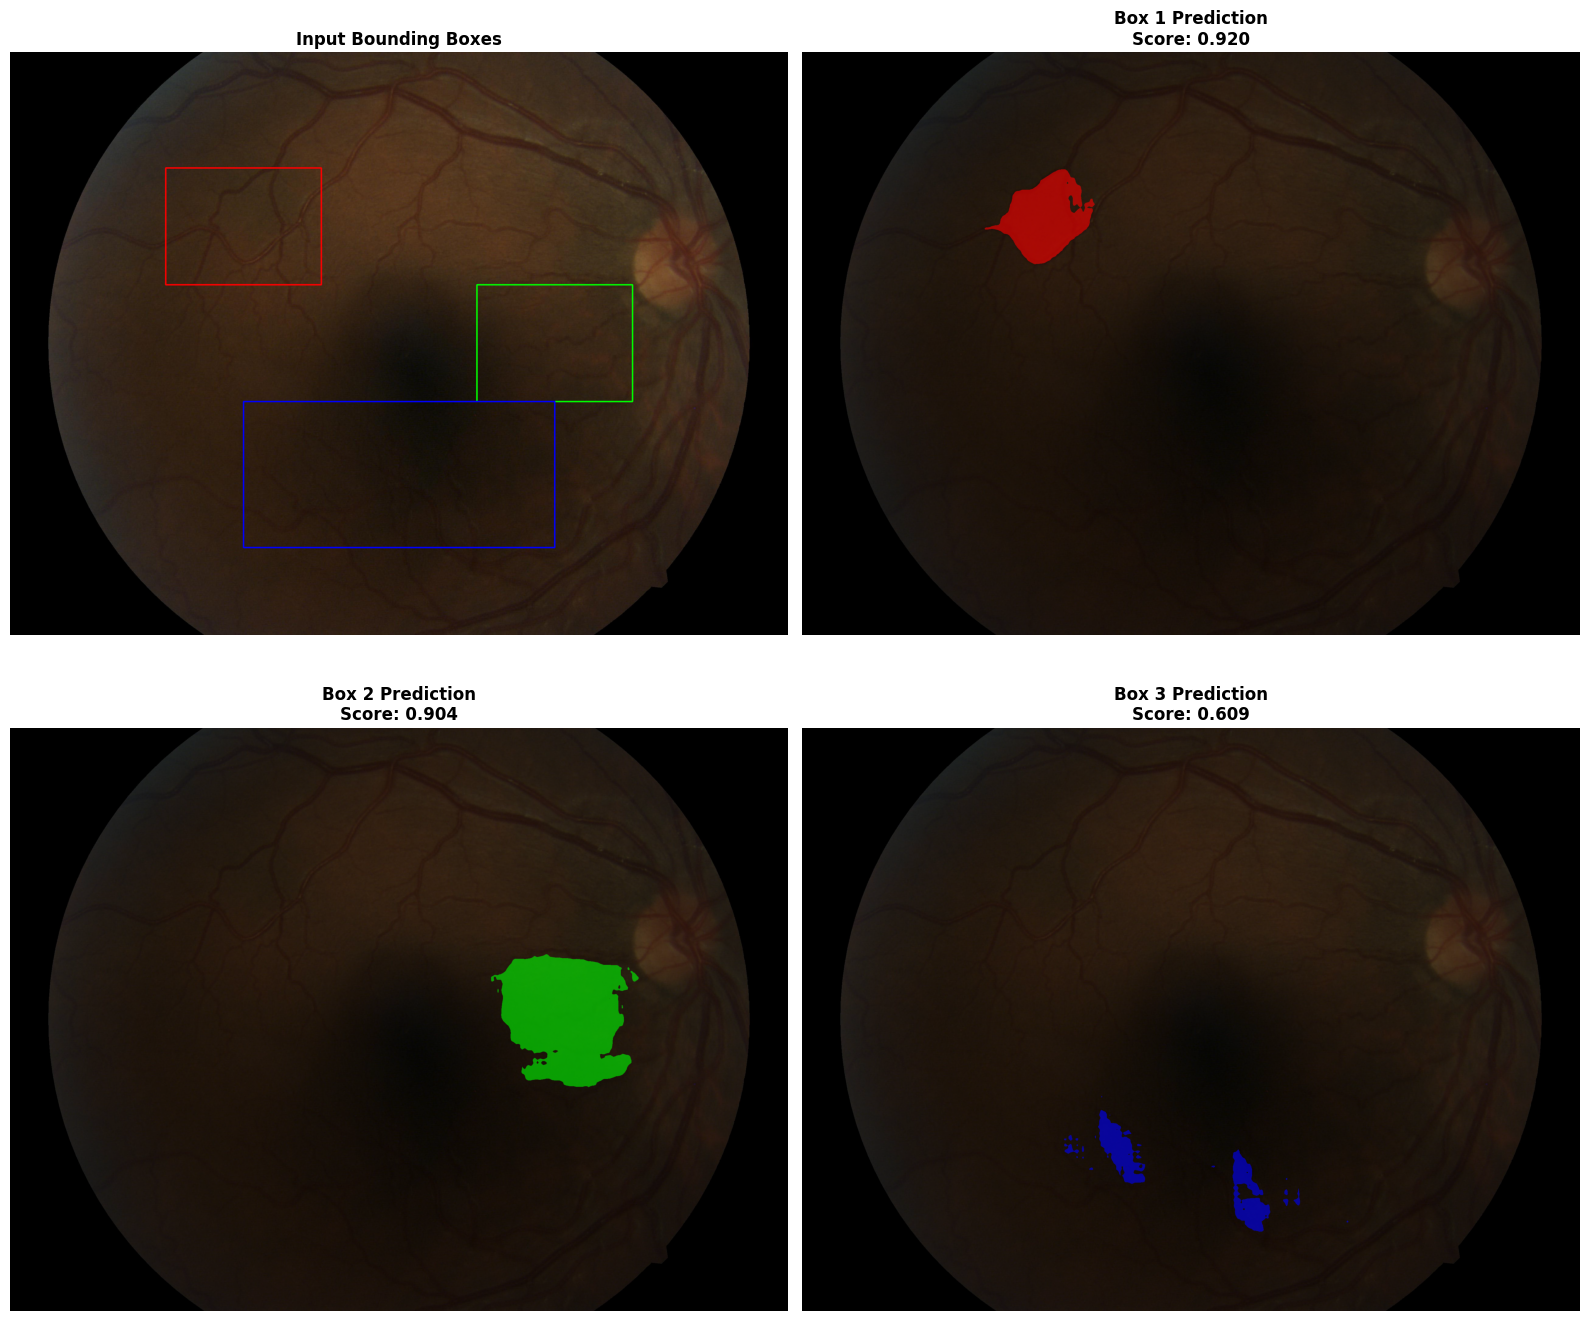

In [24]:
# Visualize bounding box results
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Original with boxes
img_with_boxes = img_rgb.copy()
colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255)]

for box, color in zip(input_boxes, colors):
    pt1 = tuple(box[0].astype(int))
    pt2 = tuple(box[1].astype(int))
    cv2.rectangle(img_with_boxes, pt1, pt2, color, 3)

axes[0, 0].imshow(img_with_boxes)
axes[0, 0].set_title('Input Bounding Boxes', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Show predictions
for idx, (mask, score) in enumerate(zip(masks_bbox, scores_bbox)):
    row, col = (0, 1) if idx == 0 else (1, idx - 1)
    
    # Create overlay
    overlay = img_rgb.copy().astype(float) * 0.6
    overlay[mask] = overlay[mask] * 0.4 + np.array(colors[idx % 3]) * 0.6
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)
    
    axes[row, col].imshow(overlay)
    axes[row, col].set_title(f'Box {idx + 1} Prediction\nScore: {score:.3f}', 
                            fontsize=12, fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## 6. Multi-Image Automatic Segmentation

In [25]:
# Process multiple images
sample_indices = [5, 10, 15, 20]
sample_images = [images[i] for i in sample_indices if i < len(images)]

print(f"Processing {len(sample_images)} sample images...")
print("This may take several minutes...\n")

segmentation_results = []

for img_idx, img_path in enumerate(sample_images):
    print(f"[{img_idx + 1}/{len(sample_images)}] Processing {Path(img_path).name}...")
    
    # Load image
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Generate masks
    masks = mask_generator.generate(img_rgb)
    
    segmentation_results.append({
        'path': img_path,
        'image': img_rgb,
        'masks': masks,
        'num_masks': len(masks)
    })
    
    print(f"  Generated {len(masks)} masks")

print("\nProcessing complete!")

Processing 4 sample images...
This may take several minutes...

[1/4] Processing 19626_right.jpeg...
  Generated 11 masks
[2/4] Processing 19802_right.jpeg...
  Generated 11 masks
[3/4] Processing 19859_right.jpeg...
  Generated 5 masks
[4/4] Processing 19953_right.jpeg...
  Generated 4 masks

Processing complete!


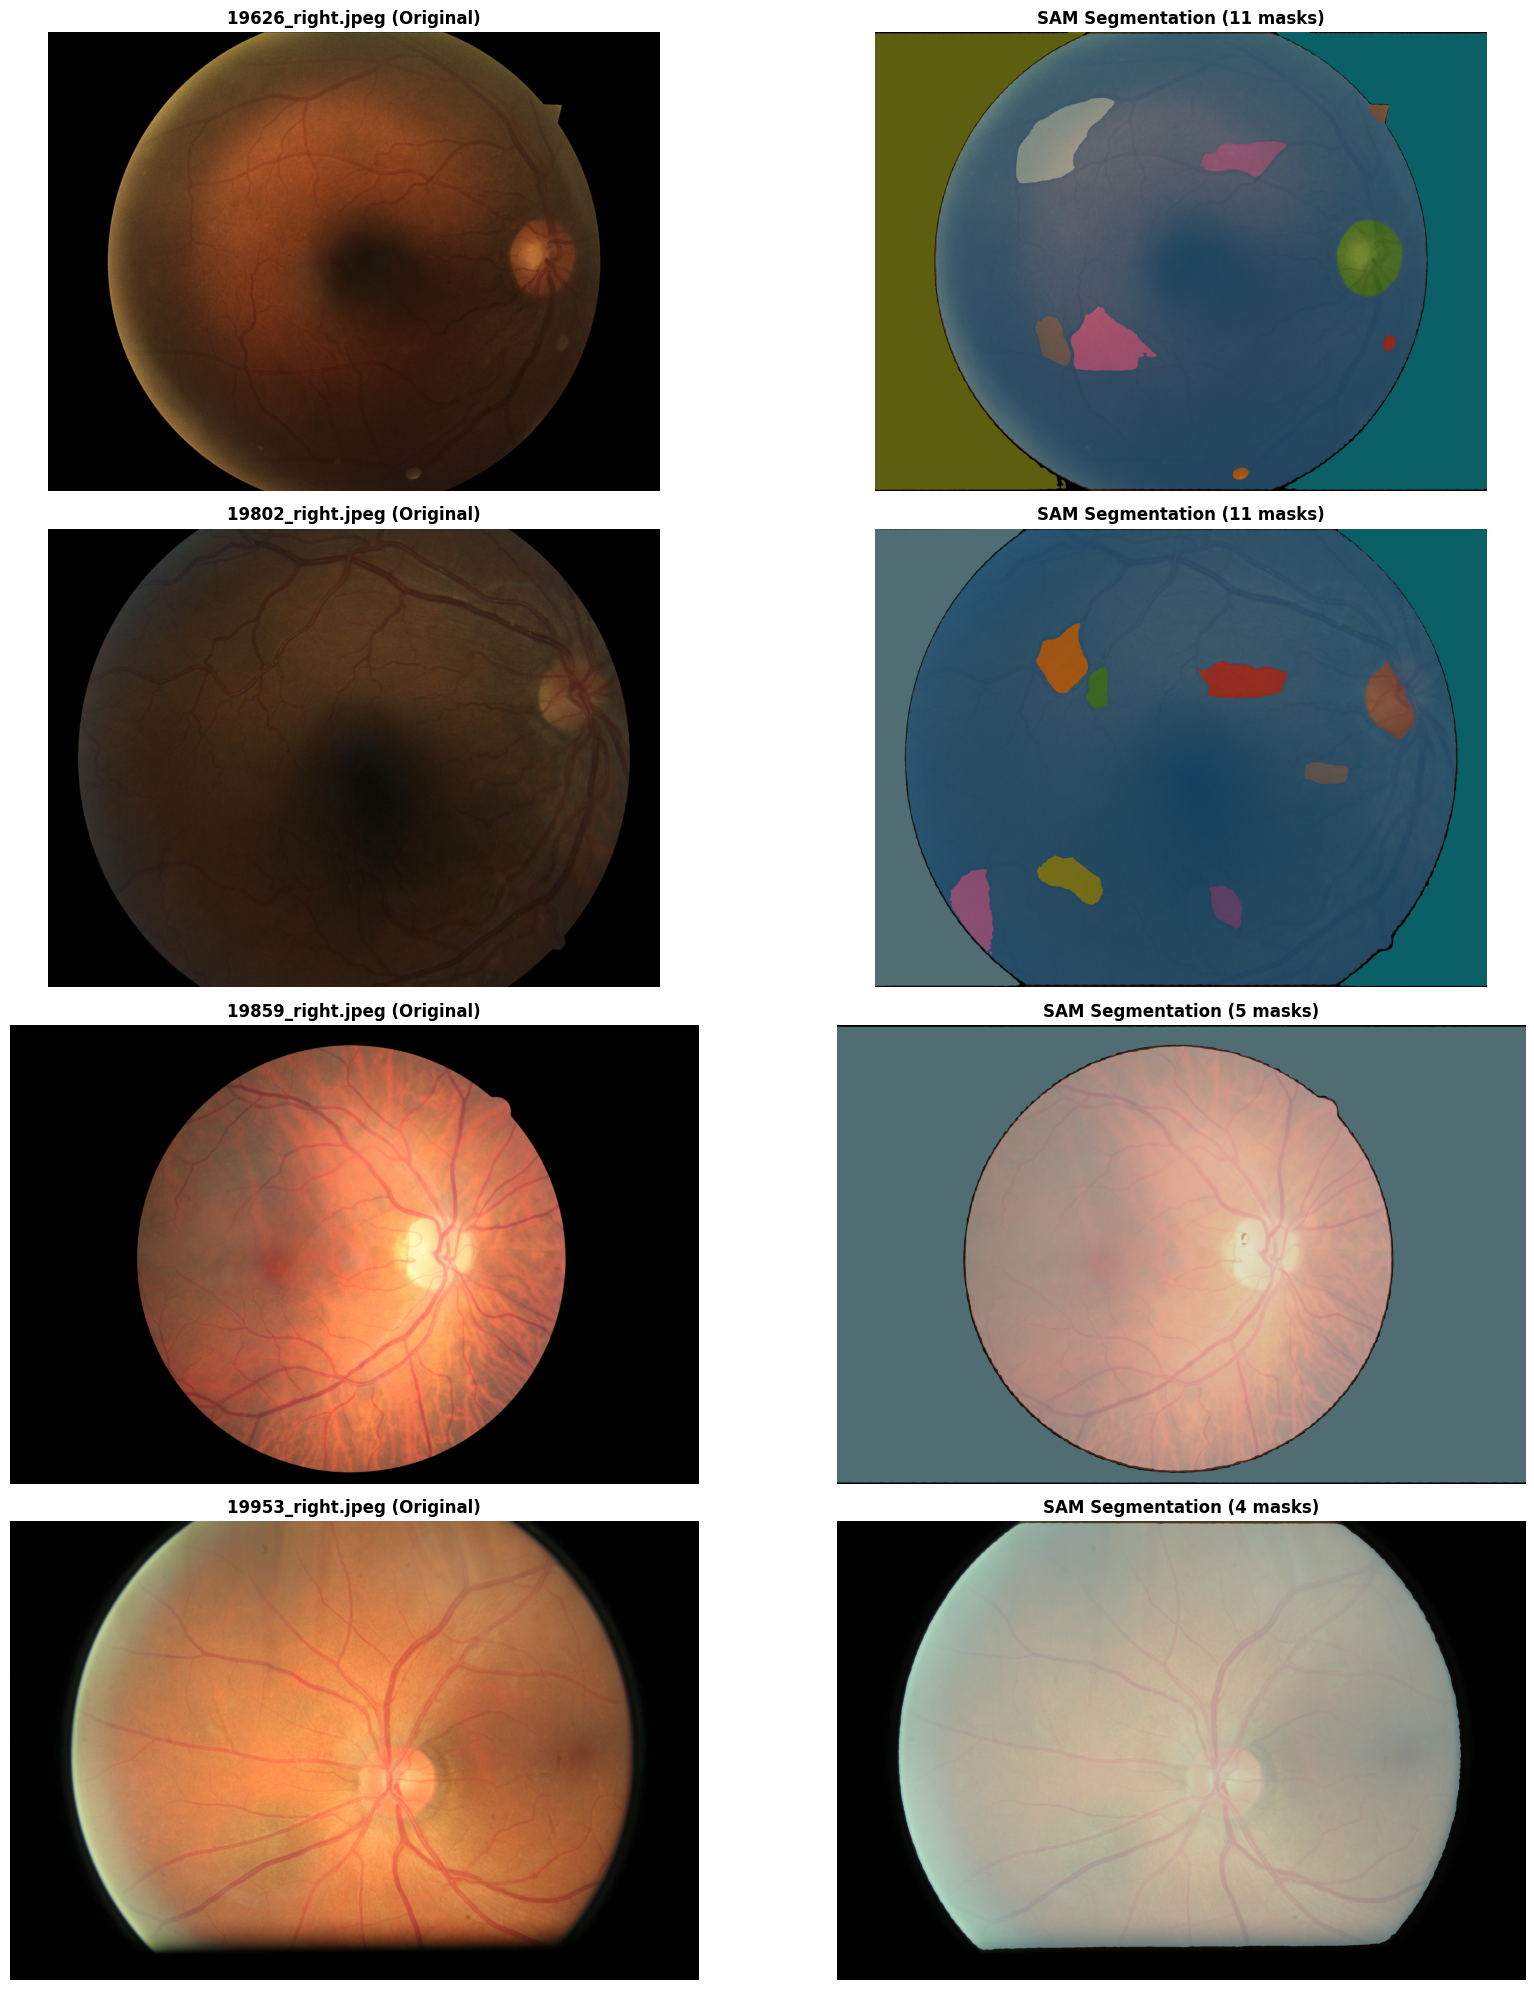

In [26]:
# Visualize results
fig, axes = plt.subplots(len(segmentation_results), 2, figsize=(18, 5 * len(segmentation_results)))

if len(segmentation_results) == 1:
    axes = axes.reshape(1, -1)

for row, result in enumerate(segmentation_results):
    img = result['image']
    masks = result['masks']
    
    # Original
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"{Path(result['path']).name} (Original)", fontweight='bold')
    axes[row, 0].axis('off')
    
    # Segmented
    overlay, _ = show_masks(img, masks, cmap_name='tab20')
    axes[row, 1].imshow(overlay)
    axes[row, 1].set_title(f"SAM Segmentation ({len(masks)} masks)", fontweight='bold')
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()

## 7. Extract Mask Properties and Features

In [27]:
def extract_sam_features(image, masks):
    """
    Extract features from SAM masks for analysis and classification.
    """
    features = {
        'num_masks': len(masks),
        'total_area': 0,
        'coverage': 0,
        'mean_area': 0,
        'mask_sizes': [],
        'stability_scores': [],
        'predicted_ious': [],
        'regions': []
    }
    
    h, w = image.shape[:2]
    total_pixels = h * w
    
    areas = []
    
    for mask_data in masks:
        mask = mask_data['segmentation']
        area = mask.sum()
        
        areas.append(area)
        features['total_area'] += area
        
        if 'stability_score' in mask_data:
            features['stability_scores'].append(mask_data['stability_score'])
        
        if 'predicted_iou' in mask_data:
            features['predicted_ious'].append(mask_data['predicted_iou'])
        
        # Extract mean color in this region
        region_pixels = image[mask]
        if len(region_pixels) > 0:
            mean_color = region_pixels.mean(axis=0)
            features['regions'].append({
                'area': area,
                'mean_color': mean_color,
                'bbox': mask_data.get('bbox', None)
            })
    
    features['mask_sizes'] = areas
    features['coverage'] = features['total_area'] / total_pixels
    
    if areas:
        features['mean_area'] = np.mean(areas)
    
    return features

# Extract features from all results
print("\nSAM Mask Analysis:")
print("=" * 90)
print(f"{'Image':<30} {'Masks':<8} {'Coverage%':<12} {'Mean Area':<12} {'Avg Stability':<15}")
print("-" * 90)

all_features = []

for result in segmentation_results:
    features = extract_sam_features(result['image'], result['masks'])
    all_features.append(features)
    
    img_name = Path(result['path']).name
    avg_stability = np.mean(features['stability_scores']) if features['stability_scores'] else 0
    
    print(f"{img_name:<30} {features['num_masks']:<8} "
          f"{features['coverage']*100:<12.2f} {features['mean_area']:<12.0f} "
          f"{avg_stability:<15.3f}")

print("=" * 90)


SAM Mask Analysis:
Image                          Masks    Coverage%    Mean Area    Avg Stability  
------------------------------------------------------------------------------------------
19626_right.jpeg               11       104.20       477305       0.962          
19802_right.jpeg               11       103.68       463292       0.945          
19859_right.jpeg               5        99.65        3000226      0.954          
19953_right.jpeg               4        68.62        1404254      0.943          


## 8. Filter Masks by Quality

In [28]:
def filter_high_quality_masks(masks, stability_threshold=0.8, iou_threshold=0.85, min_area=100):
    """
    Filter masks based on quality metrics.
    
    Higher stability_score and predicted_iou = better masks
    """
    filtered = []
    
    for mask_data in masks:
        stability = mask_data.get('stability_score', 0)
        predicted_iou = mask_data.get('predicted_iou', 0)
        area = mask_data['segmentation'].sum()
        
        # Apply filters
        if (stability >= stability_threshold and 
            predicted_iou >= iou_threshold and 
            area >= min_area):
            filtered.append(mask_data)
    
    return filtered

# Filter masks and compare
print("\nMask Filtering Results:")
print("=" * 70)
print(f"{'Image':<30} {'Total':<8} {'High Quality':<15} {'Reduction%':<15}")
print("-" * 70)

filtered_results = []

for result in segmentation_results:
    original_count = len(result['masks'])
    filtered_masks = filter_high_quality_masks(
        result['masks'],
        stability_threshold=0.85,
        iou_threshold=0.88
    )
    filtered_count = len(filtered_masks)
    reduction = (1 - filtered_count / original_count) * 100
    
    filtered_results.append({
        'path': result['path'],
        'image': result['image'],
        'masks': filtered_masks
    })
    
    img_name = Path(result['path']).name
    print(f"{img_name:<30} {original_count:<8} {filtered_count:<15} {reduction:<15.1f}")

print("=" * 70)


Mask Filtering Results:
Image                          Total    High Quality    Reduction%     
----------------------------------------------------------------------
19626_right.jpeg               11       10              9.1            
19802_right.jpeg               11       9               18.2           
19859_right.jpeg               5        3               40.0           
19953_right.jpeg               4        4               0.0            


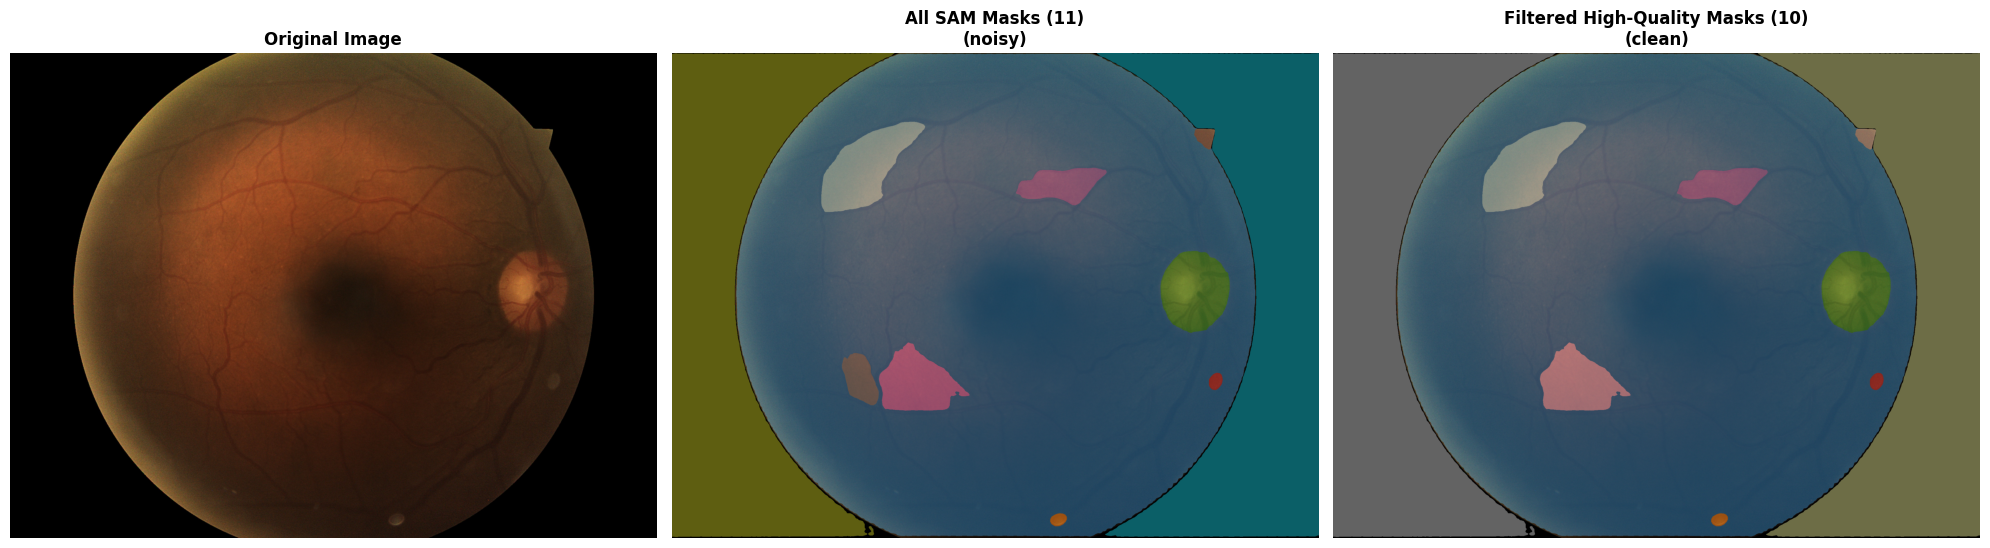

In [29]:
# Visualize before/after filtering
if len(segmentation_results) > 0:
    result = segmentation_results[0]
    filtered = filtered_results[0]
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    
    # Original
    axes[0].imshow(result['image'])
    axes[0].set_title('Original Image', fontweight='bold')
    axes[0].axis('off')
    
    # All masks
    overlay_all, _ = show_masks(result['image'], result['masks'], cmap_name='tab20')
    axes[1].imshow(overlay_all)
    axes[1].set_title(f"All SAM Masks ({len(result['masks'])})\n(noisy)", fontweight='bold')
    axes[1].axis('off')
    
    # Filtered high-quality masks
    overlay_filtered, _ = show_masks(result['image'], filtered['masks'], cmap_name='tab20')
    axes[2].imshow(overlay_filtered)
    axes[2].set_title(f"Filtered High-Quality Masks ({len(filtered['masks'])})\n(clean)", fontweight='bold')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

## 9. Interactive Segmentation (Example Framework)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.widgets import Button
matplotlib.use('TkAgg')  # or 'Qt5Agg'

def interactive_sam_segmentation(image_path, predictor):
    """Interactive segmentation with matplotlib."""
    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(img_rgb)
    
    points = []
    labels = []
    
    def on_click(event):
        if event.inaxes != ax:
            return
        
        # Collect clicked point
        x, y = int(event.xdata), int(event.ydata)
        points.append([x, y])
        
        # 1 = include, 0 = exclude
        label = 1 if event.button == 1 else 0  # Left click = include
        labels.append(label)
        
        # Visualize click
        color = 'green' if label == 1 else 'red'
        ax.plot(x, y, 'o', color=color, markersize=10, markeredgewidth=2,
               markerfacecolor='none')
        plt.draw()
        
        if len(points) >= 1:
            # Run prediction after each click
            predictor.set_image(img_rgb)
            masks, scores, _ = predictor.predict(
                point_coords=np.array(points),
                point_labels=np.array(labels),
                multimask_output=True
            )
            
            best_mask = masks[np.argmax(scores)]
            # Visualize result...
    
    fig.canvas.mpl_connect('button_press_event', on_click)
    plt.show()

interactive_sam_segmentation('data/1-mild/231_left.jpeg', predictor)

## 10. Integration with DR Classification Pipeline

In [ ]:
def create_sam_preprocessing_pipeline(image_path, predictor, mask_generator):
    """
    Create preprocessing pipeline using SAM for DR classification.
    
    Returns: Preprocessed image with segmentation-based enhancements
    """
    # Load image
    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Generate automatic masks
    masks = mask_generator.generate(img_rgb)
    
    # Filter high-quality masks
    high_quality_masks = filter_high_quality_masks(
        masks,
        stability_threshold=0.85,
        iou_threshold=0.88
    )
    
    # Create attention map from masks
    attention_map = np.zeros(img_rgb.shape[:2], dtype=np.float32)
    for mask_data in high_quality_masks:
        mask = mask_data['segmentation']
        attention_map[mask] += 1
    
    # Normalize attention map
    if attention_map.max() > 0:
        attention_map = attention_map / attention_map.max()
    
    # Apply attention-based enhancement
    # Enhance regions with high segmentation confidence
    enhanced = img_rgb.copy().astype(float)
    for c in range(3):
        enhanced[:, :, c] = enhanced[:, :, c] * (0.5 + attention_map)
    
    enhanced = np.clip(enhanced, 0, 255).astype(np.uint8)
    
    return enhanced, high_quality_masks, attention_map

# Example: Apply preprocessing to first sample
if len(images) > 0:
    print("Applying SAM-based preprocessing...")
    enhanced, masks_used, attention = create_sam_preprocessing_pipeline(
        images[10],
        predictor,
        mask_generator
    )
    
    # Visualize
    img_bgr = cv2.imread(images[10])
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(img_rgb)
    axes[0].set_title('Original', fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(attention, cmap='hot')
    axes[1].set_title('Attention Map from SAM', fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(enhanced)
    axes[2].set_title('Enhanced for Classification', fontweight='bold')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

NameError: name 'images' is not defined

: 

## Summary

### SAM Advantages:
- **Zero-shot**: Works on any image without training
- **Flexible prompts**: Points, bounding boxes, or text (with CLIP integration)
- **Multiple predictions**: Returns mask hypotheses with confidence scores
- **High quality**: Produces precise, fine-grained masks
- **Interactive**: Can be refined iteratively with additional prompts

### SAM vs YOLOv8:
| Aspect | SAM | YOLOv8-seg |
|--------|-----|----------|
| Training needed | No | Yes (or use pretrained) |
| Speed | Slower | Faster |
| Flexibility | Very high | Fixed classes |
| Quality | Excellent | Very good |
| Interactivity | Natural | Batch inference |
| Best for | Exploration, refinement | Production, known classes |

### Recommended Workflow:
1. **Exploration phase**: Use SAM for flexible segmentation and analysis
2. **Validation phase**: Refine with point/box prompts
3. **Production phase**: Use YOLOv8 if specific classes are defined, or combine both

### Next Steps:
- Integrate SAM masks with YOLOv8 detections for comprehensive analysis
- Use attention maps as features for DR classification
- Implement interactive annotation tool for dataset creation
- Fine-tune on domain-specific retinal structures